# Data Preparation

In this notebook, we discuss the quality of the data, visualize the completeness, and perform data cleaning and imputation to support model building.

Not shown here is how these data cleaning and transformation decisions were informed by iteratively testing the performance of the data on a baseline prediction case: training a tree-based classical ML model on a historical training period and testing it on a subsequent testing period. As the volume and quality of data for developed markets is greater than that for emerging markets, these baseline tests were mainly used to create a pipeline of preprocessing and feature engineering steps for developed markets and then adapted to emerging markets.

In [1]:
import os
import dotenv
dotenv.load_dotenv()
username = os.getenv("HUGGINGFACE_USERNAME")

This project uses open source data to explore financial crisis prediction in developed and emerging markets. Data sources include:
1. **World Bank** - World Development Indicators
2. **Organization for Economic Development (OECD)** - Key Economic Indicators
3. **Jordà-Schularick-Taylor (JST) Macrohistory Database**

Timely availability of quality data for emerging markets is an issue that precludes the training of early warning prediction models. Below is a table showing the availability of data in the relevant databases. The developed countries comprise the 17 well-studied economies in the first plot in <a href>`0.Introduction.ipynb`</a>. The emerging markets comprise the economies visualized in the second plot in <a href>`0.Introduction.ipynb`</a>, grouped by region.

| Data Set | Country Category | Number of Countries | Variables | Maximum Temporal Range | Temporal Frequency | Average Completeness | 
|----|----|----|----|----|----|----|
| World Bank | Developed | 17 | 455+ | 1960-2025 | Annual | 51.7% |
|| Emerging (Africa) | 33 | 511+ | 1960-2025 | Annual | 35.1% |
|| Emerging (Americas) | 22 | 511+ | 1960-2025 | Annual | 47.5% |
|| Emerging (Asia) | 29 | 511+ | 1960-2025 | Annual | 33.1% |
| OECD | Developed | 17 | 37 | 1914-2024 | Monthly / Quarterly | 32.5% |
|| Emerging (Africa) | 1 | 61 | 1957-2024 | Monthly / Quarterly | 32.1% |
|| Emerging (Americas) | 5 | 61 | 1957-2024 | Monthly / Quarterly | 25.7% |
|| Emerging (Asia) | 3 | 61 | 1951-2024 | Monthly / Quarterly| 25.4% |
| JST | Developed | 17 (+ Ireland) | 55 | 1870-2020 | Annual | 78.2% |
|| Emerging (Africa) | 0 | | | | |
|| Emerging (Americas) | 0 | | | | |
|| Emerging (Asia) | 0 | | | | |

Data quality can be checked by importing the class `PreprocessPipeline` and using the class methods associated with it. In particular, the above table can be regenerated by first loading the appropriate dataset from Hugging Face Hub and calling the `print_info()` function.

```python
from src.data.processor import PreprocessPipeline

for source in ['WORLDBANK', 'OECD', 'JST']:
    for subset in ['developed', 'emerging']:
        # automatically reads the appropriate dataset from Hugging Face
        pipeline = PreprocessPipeline(source, subset=subset)
        
        # prints completeness of data, subset by countries, if provided
        pipeline.print_info(countries)
```

As a bonus, Yahoo Finance data was also compiled; however it has been ommitted from the table above as it is not always clear how to associate specific stocks and ETFs to individual countries and whether they might add nuance or noise to a country's economic picture. Furthermore, the high daily resolution of the data is limited in coverage from late 1990s / early 2000s onwards. A potential extension of this project could be to explore how a baseline model deployed in production can adapt to new, higher frequency signals with minimal retraining. For now, we focus on the annual and monthly data as the crisis labels we are predicting are also reported at an annual resolution.

## Imputation

A challenge for this project was dealing with missing data in an appropriate manner. Given the relatively low completeness of information, particularly in the case of emerging markets, and the relatively large scale of imputation required to fill the many columns of missing data, there was a need to come up with some creative approaches to perform useful imputations while not introducing any data leakage or look-ahead bias. Here we describe the data preprocessing steps by database and by country group.

### World Bank
The World Bank data set was the most complete and comprehensive in terms of its coverage of countries and its repository of economic variables. As the World Bank is also a reputed source for such information, it was generally assumed that all values were accurately reported.

#### Developed
The main method of filling missing values for this dataset was history-based KNN. This was performed for country and column combinations where missing data was interspersed between valid observations (i.e. in the region of interpolation). Each row that required interpolation was matched with the K-nearest historical neighbors which could be any row in the country's history and/or any country in any date in history up to and including the current date. Any missing column was then imputed with the inverse average of the nearest neighbors, by Manhattan distance, which is a more useful metric of distance than Euclidean distance in a large dimensional space.

For imputation of data where there were only valid observations in the past, ARIMA was used to forward fill. This was performed after history-based KNN so that the ARIMA models had sufficient historical data for each country and column to perform. Finally, history-based KNN was repeated to fill any remaining values. The rest of history was then backfilled with the global median or zero.

In [ ]:
from src.data.processor import PreprocessPipeline
from src.data.data_utilities import upload_to_huggingface

# (1122, 455)
pipeline = PreprocessPipeline("WORLDBANK", subset="developed")

# drop 2 static columns
pipeline.drop_static()
# drop column GFDD.OI.19 (a proxy crisis label)
# drop 354 columns with less than 80% completeness
pipeline.drop_columns(columns=['GFDD.OI.19'], completeness=0.8)
# trim timeseries to period more than 80% completeness
# (1960-01-01 onwards)
pipeline.trim_timeseries(completeness=0.8)

# resample the data to annual frequency to ensure no gaps
pipeline.resample(frequency="Y")
# if a column is all NaN or all zero for a country, fill with zero
# (equivalent to no data or no relevance)
pipeline.zero_fill()

# obtain an imputation mask to perform imputation
# 1. imputation of data where there is an observation before and after
mask = pipeline.get_imputation_mask(include_before=False, include_after=False)
pipeline.knn_iterative_imputer(mask=mask, distance_metric='manhattan', k=5) # 270 values imputed

# 2. imputation of data where there is an observation before but none after
# (i.e. a reporting lag, database error, obsolete column)
pipeline.arima_fill() # 481 values imputed

# 3. imputation of data where there is no observation before
# (i.e. new variable, not measured historically)
mask = pipeline.get_imputation_mask(include_before=True, include_after=False)
pipeline.knn_iterative_imputer(mask=mask, distance_metric='manhattan', k=3) # 7552 values imputed
pipeline.backfill('median') # backfill 41 values with global median
# trim timeseries to period more than 95% complete
# (1962-12-31 to 2025-08-21)
pipeline.trim_timeseries(0.95)
pipeline.backfill('zero') # backfill 1023 values with zero

# (1053, 99)
upload_to_huggingface(pipeline.df.set_index('Date'), repo_name=f"imputed-worldbank", config_name="developed")

In [3]:
display(pipeline.df)

,Country,Date,BM.KLT.DINV.CD.WD,BM.KLT.DINV.WD.GD.ZS,BX.KLT.DINV.CD.WD,BX.KLT.DINV.WD.GD.ZS,FI.RES.TOTL.CD,FI.RES.XGLD.CD,FP.CPI.TOTL,FP.CPI.TOTL.ZG,...,PA.NUS.FCRF,GFDD.DI.01,GFDD.DI.02,GFDD.DI.04,GFDD.DI.05,GFDD.DI.06,GFDD.DI.08,GFDD.DI.12,GFDD.OI.07,GFDD.SI.04
11,Australia,1962-12-31,0.000000e+00,0.000000,0.000000e+00,0.000000,1.358961e+09,1.168180e+09,8.116545,-0.319489,...,0.892857,17.766160,36.076760,86.539610,45.103230,5.611384,40.481380,17.766160,6.747395e+04,43.887240
24,Australia,1963-12-31,0.000000e+00,0.000000,0.000000e+00,0.000000,1.842726e+09,1.634000e+09,8.168574,0.641026,...,0.892857,18.196540,37.610370,90.745490,45.640500,3.835626,41.429630,18.196540,7.316104e+04,43.921570
43,Australia,1964-12-31,0.000000e+00,0.000000,0.000000e+00,0.000000,1.906895e+09,1.680020e+09,8.402706,2.866242,...,0.892857,19.021950,38.424320,90.710130,46.375580,3.935140,42.457050,19.021950,8.070759e+04,44.802790
65,Australia,1965-12-31,0.000000e+00,0.000000,0.000000e+00,0.000000,1.565328e+09,1.317030e+09,8.688866,3.405573,...,0.892857,19.986200,38.661530,90.139410,45.362220,4.229285,41.881800,19.986200,8.360749e+04,47.720480
76,Australia,1966-12-31,0.000000e+00,0.000000,0.000000e+00,0.000000,1.569256e+09,1.344040e+09,8.975026,3.293413,...,0.892857,20.966340,40.031270,91.980920,45.683910,3.490007,42.117980,20.966340,8.672989e+04,49.780030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
980,United States,2019-12-31,1.149270e+11,0.533552,3.159840e+11,1.466965,5.167006e+11,1.184377e+11,117.244195,1.812210,...,1.000000,52.178020,64.006810,85.424860,76.905010,10.920800,84.525320,191.364200,1.400000e+07,61.730640
992,United States,2020-12-31,2.823310e+11,1.322139,1.370660e+11,0.641872,6.283697e+11,1.338491e+11,118.690502,1.233584,...,1.000000,54.569080,74.168460,76.751030,91.688880,22.466670,101.216900,216.559100,1.610000e+07,53.913000
1004,United States,2021-12-31,3.419540e+11,1.443991,4.758050e+11,2.009212,7.161523e+11,2.401973e+11,124.266414,4.697859,...,1.000000,55.715296,78.776967,69.125079,96.658140,24.601870,107.737621,218.509420,1.759451e+07,51.986648
1033,United States,2022-12-31,3.885100e+11,1.493873,4.089820e+11,1.572591,7.066442e+11,2.327166e+11,134.211206,8.002800,...,1.000000,55.928202,80.867016,64.949784,96.285372,23.067536,110.285001,221.925190,1.873056e+07,51.986648


The data transformation steps described above were implemeneted using the `PreprocessPipeline` object, which conveniently stores the preproccess log to aid in quality checking and reproducibility.

```python
# view a log of preprocess steps applied to pipeline
print(pipeline.preprocess_log)
```
Additionally, the preprocess steps and the time taken for each are logged in <a href>logs/PreprocessPipeline_logs.txt</a>.

At any given point, it is useful to plot a subset of the data using the `.plot_sample()`. This class method creates a figure that plots 9 difference variables from the dataset, prioritizing the ones that have missing values to assist in making decisions on preprocessing strategy.

```python
# plot a susbet of columns, highlighting specific countries
pipeline.plot_sample(countries = ['United States','Japan'])
```

#### Emerging
Due to the sheer number of countries present in the emerging markets subset, only history-based KNN was used to impute values. To enrich the imputation quality, developed markets were concatenated to the dataframe during the imputation step so that they may also appear as nearest neighbors.

In [ ]:
from src.data.processor import PreprocessPipeline
from src.data.data_utilities import upload_to_huggingface
from datasets import load_dataset
import pandas as pd

# (5353, 511)
pipeline = PreprocessPipeline("WORLDBANK", subset="emerging")
# rename countries for consistency
country_rename = {
    'Congo Dem. Rep.': 'Congo, Dem. Rep.',
    'Congo Rep.': 'Congo, Rep.',
    'Egypt, Arab Rep.': 'Egypt',
    'Egypt Arab Rep.': 'Egypt',
    'Gambia The': 'Gambia, The',
    'Iran Islamic Rep.': 'Iran, Islamic Rep.',
    'Taiwan China': 'Taiwan, China',
    'Turkiye': 'Turkey',
    'Venezuela RB': 'Venezuela, RB',
    'Viet Nam': 'Vietnam',
    'Yemen Rep.': 'Yemen, Rep.'
}
pipeline.df['Country'] = pipeline.df['Country'].replace(country_rename)
# keep most complete (Country, Date) row
pipeline.df['is_null'] = pipeline.df.T.isnull().sum()
pipeline.df.sort_values('is_null', ascending=False, inplace=True)
pipeline.df.drop_duplicates(subset = ['Country', 'Date'], keep='last', inplace=True, ignore_index=True)

# drop 154 static rows
pipeline.drop_static()
# drop column GFDD.OI.19 (a proxy crisis label) and temporary column 'is_null'
# drop 328 columns with less than 60% completeness
pipeline.drop_columns(columns=['is_null', 'GFDD.OI.19'], completeness=0.6)
# trim timeseries to period more than 80% completeness
# (1965-01-01 onwards)
pipeline.trim_timeseries(completeness=0.8)
# resample the data to annual frequency to ensure no gaps
pipeline.resample(frequency="Y")

# concatenate with the developed markets data for history-based KNN imputation
developed = load_dataset(f"{username}/imputed-worldbank", 'developed')['train'].to_pandas()
emerging_columns = pipeline.df.columns.tolist()
emerging_countries = pipeline.df['Country'].unique().tolist()
pipeline.df = pd.concat([pipeline.df, developed]).reset_index().sort_values('Date')

# obtain an imputation mask to perform imputation
# 1. imputation of data where there is an observation before and after
mask = pipeline.get_imputation_mask(include_before=False, include_after=False)
pipeline.knn_iterative_imputer(mask=mask, distance_metric='manhattan', k=10) # 6351 values imputed

# 2. imputation of data where there is an observation before but none after
# (i.e. a reporting lag, database error, obsolete column)
mask = pipeline.get_imputation_mask(include_before=False, include_after=True)
pipeline.knn_iterative_imputer(mask=mask, distance_metric='manhattan', k=10) # 22662 values imputed

# 3. imputation of data where there is no observation before
# (i.e. new variable, not measured historically)
mask = pipeline.get_imputation_mask(include_before=True, include_after=False)
pipeline.knn_iterative_imputer(mask=mask, distance_metric='manhattan', k=5) # 126016 values imputed

# 4. imputation of all other columns
pipeline.knn_iterative_imputer(distance_metric='manhattan', k=3) # 51987 values imputed

# remove developed countries
pipeline.df = pipeline.df[pipeline.df['Country'].isin(emerging_countries)]
pipeline.df = pipeline.df[emerging_columns]
# remove Iran, Islamic Rep. and Swaziland due to crisis labelling issues
pipeline.df = pipeline.df[~pipeline.df['Country'].isin(['Iran, Islamic Rep.', 'Swaziland'])]
pipeline.drop_static() # drop 0 static rows/columns
# trim timeseries to period more than 95% complete
# (1970-12-31 onwards)
pipeline.trim_timeseries(0.95)
# resample the data to annual frequency to ensure no gaps
pipeline.resample(frequency="Y")

pipeline.arima_fill() # 6 values imputed
pipeline.backfill('median') # backfill 2998 values with global median
pipeline.backfill('zero') # backfill 0 values with 0
# if a column is all NaN or all zero for a country, fill with zero
# (equivalent to no data or no relevance)
pipeline.zero_fill() # fill 1190 values with 0
pipeline.knn_iterative_imputer(distance_metric='manhattan', k=3) # 276 values imputed

# (4050, 183)
upload_to_huggingface(pipeline.df.set_index('Date'), repo_name=f"imputed-worldbank", config_name="emerging")

In [5]:
display(pipeline.df)

,Country,Date,BG.GSR.NFSV.GD.ZS,BM.GSR.CMCP.ZS,BM.GSR.FCTY.CD,BM.GSR.GNFS.CD,BM.GSR.INSF.ZS,BM.GSR.MRCH.CD,BM.GSR.NFSV.CD,BM.GSR.TOTL.CD,...,GFDD.DI.01,GFDD.DI.02,GFDD.DI.04,GFDD.DI.05,GFDD.DI.06,GFDD.DI.08,GFDD.DI.12,GFDD.OI.02,GFDD.OI.07,GFDD.SI.04
0,Afghanistan,1970-12-31,6.616983,20.205958,4.341871e+08,1.712587e+09,7.749097,1.319570e+09,4.028859e+08,2.134815e+09,...,3.256675,3.256675,20.951810,13.203320,12.286970,2.149939,3.256675,2.149939,1502.575000,151.477500
1,Afghanistan,1971-12-31,6.711896,20.723748,4.155735e+08,1.659489e+09,7.638771,1.275536e+09,3.890461e+08,2.079219e+09,...,2.822212,2.822212,17.688930,14.036420,13.132460,2.605586,2.822212,2.605586,1619.583000,108.313900
2,Afghanistan,1972-12-31,6.721955,19.828478,4.141504e+08,1.654790e+09,7.444964,1.260613e+09,3.884260e+08,2.076509e+09,...,3.893315,3.893315,17.863990,18.353760,17.900890,3.414763,3.893315,3.414763,1784.525000,114.014200
3,Afghanistan,1973-12-31,6.737737,19.936755,4.118653e+08,1.640262e+09,7.494114,1.254788e+09,3.910268e+08,2.052127e+09,...,3.871410,3.871410,19.299970,18.183980,16.187740,2.993462,3.871410,2.993462,1766.865000,129.328900
4,Afghanistan,1974-12-31,6.757834,20.761395,4.096346e+08,1.634722e+09,7.438485,1.259142e+09,3.856295e+08,2.041384e+09,...,3.617114,3.617114,19.219800,16.592270,15.202620,2.716392,3.617114,2.716392,1784.728000,133.158800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3991,Zimbabwe,2019-12-31,5.881065,27.777004,3.543251e+08,5.398499e+09,12.409562,4.489261e+09,9.091063e+08,5.752824e+09,...,6.913738,9.681590,53.295110,21.935580,8.484409,20.651830,6.913738,20.651830,1780.664000,33.477600
3992,Zimbabwe,2020-12-31,4.097988,38.210650,4.805870e+08,5.489302e+09,8.429267,4.719668e+09,7.696341e+08,5.969889e+09,...,6.575891,7.767617,72.939550,18.231840,2.881772,17.868780,6.575891,17.868780,2109.637000,36.800990
3993,Zimbabwe,2021-12-31,4.336054,33.220145,6.623014e+08,8.103852e+09,10.506154,7.138423e+09,9.654284e+08,8.766153e+09,...,7.495270,9.009220,76.890140,16.125960,2.707782,15.867700,7.495270,15.867700,3439.012000,47.236020
3994,Zimbabwe,2022-12-31,5.764197,40.557963,6.306833e+08,9.568573e+09,8.666313,8.131803e+09,1.436771e+09,1.019926e+10,...,15.262290,19.026380,54.068000,22.746554,22.027682,19.209608,15.262290,19.209608,3365.857109,92.671213


History-based KNN imputation was chosen for speed. Other alternatives explored included Random Forest Regression and Gradient Boosting Regressor. These tend to take longer as each imputation requires retraining the model on a subset of the relevant historical data to avoid look-ahead bias. The following functions can be used to implement these alternatives. In general, KNN-based imputation provided sufficiently good results, especially when tuning with different values of $k$.

```python
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# initialize regressor
regressor = RandomForestRegressor()

# obtain imputation mask
mask = pipeline.get_imputation_mask(include_before=False, include_after=True)

# engineer useful temporal features from a subset of the data to assist in model training
features = pipeline.engineer_features(pipeline.df[['Country','Date','NE.GDI.FTOT.ZS','NY.GNP.PCAP.CD']])

df = pipeline.multiple_imputation(
    df = pipeline.df,
    regressor = regressor,
    mask = mask,
    # (optional) data features to train the regressor
    features = features
)
```

For emerging markets, history-based KNN was used with a higher $k$ to take advantage of the greater diversity of countries available in the dataset. A few columns were imputed using ARIMA. ARIMA fill was performed prior to the backfill with global median and zero so that these historical values had no effect on the trends learned.

### OECD
The OECD data set provided the highest resolution information but was limited in coverage to developed markets and select emerging markets.

#### Developed
Quarterly columns were forward filled to monthly resolution and a similar method of history-based KNN imputation was used to interpolate missing values. Due to the higher resolution, ARIMA was a good option to fill the latest observations.

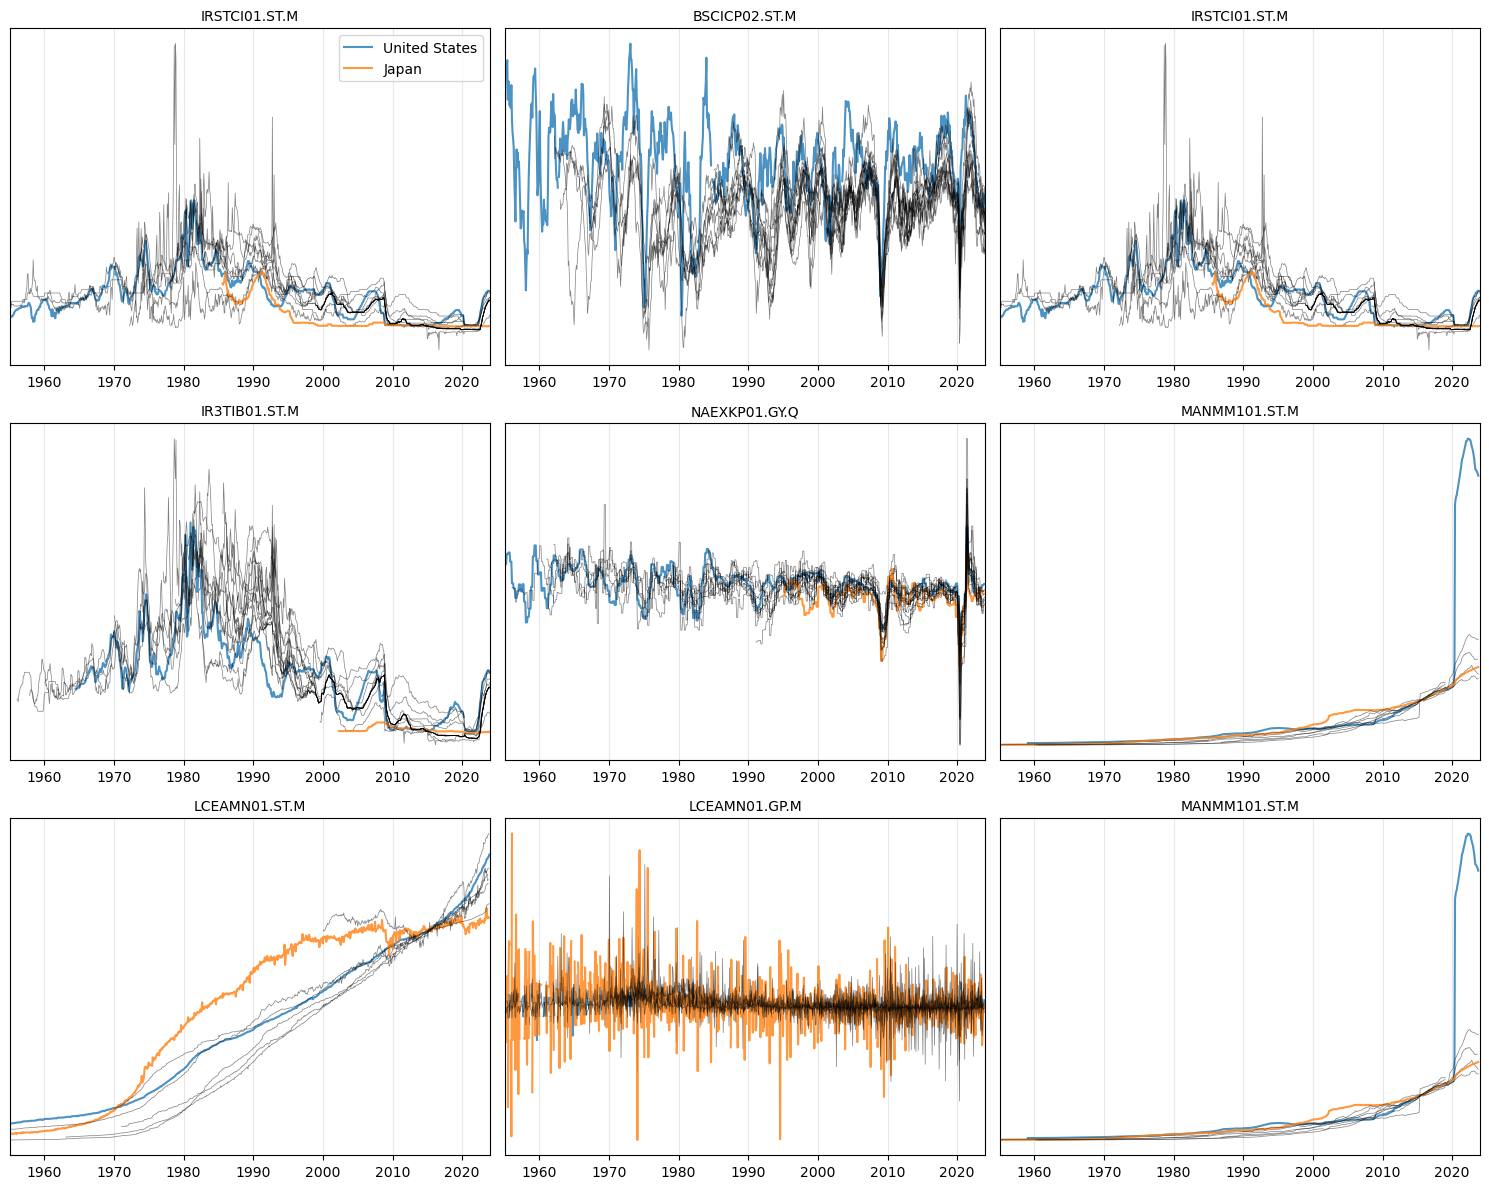

In [ ]:
from src.data.processor import PreprocessPipeline
from src.data.data_utilities import upload_to_huggingface

# (14652, 37)
pipeline = PreprocessPipeline("OECD", subset="developed")
# drop 832 static rows
pipeline.drop_static()
# resample the data to monthly frequency to ensure no gaps
pipeline.resample(frequency='M')
# forward fill quarterly columns to monthly resolution
Q_columns = [col for col in pipeline.df.columns if col.endswith('.Q')]
pipeline.forward_fill(columns=Q_columns, n=2, latest_only=False) # 60422 values forward filled
# trim timeseries to period with more than 40% completeness
# (1955-01-31 onwards)
pipeline.trim_timeseries(completeness=0.4)

pipeline.plot_sample(countries = ['United States', 'Japan'])

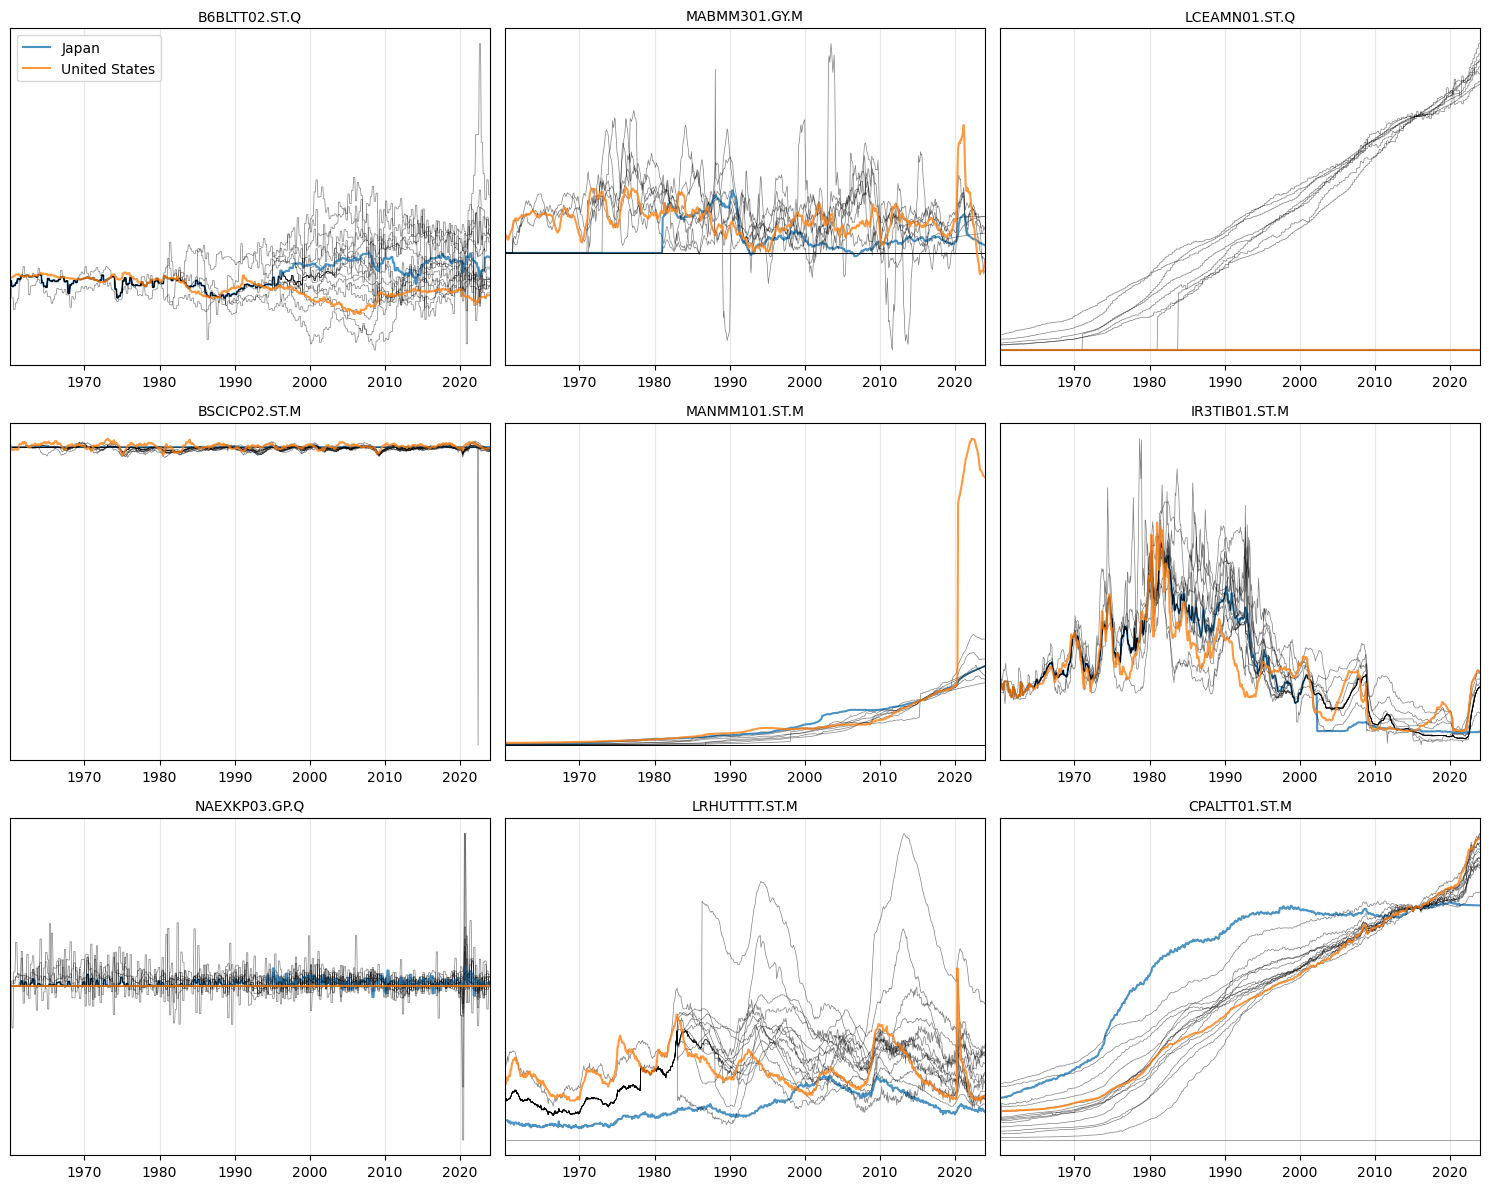

In [ ]:
# drop column LOLITOAA.ST.M (a proxy crisis label)
# drop 12 columns with less than 40% completeness
pipeline.drop_columns(columns=['LOLITOAA.ST.M'], completeness=0.4)
# if a column is all NaN or all zero for a country, fill with zero
# (equivalent to no data or no relevance)
pipeline.zero_fill() # fill 56247 values with 0

# obtain an imputation mask to perform imputation
# 1. imputation of data where there is an observation before and after
mask = pipeline.get_imputation_mask(include_before=False, include_after=False)
pipeline.knn_iterative_imputer(mask=mask) # imputes 194 cells with KNN
# trim timeseries to period with more than 95% completeness
# (1960-01-31 onwards)
pipeline.trim_timeseries(completeness=0.95)

# 2. ARIMA fill
pipeline.arima_fill() # imputes 1375 cells

# 3. backfill with global median and zero
pipeline.backfill(fill='median') # backfill 55187 cells with global median
pipeline.backfill(fill='zero') # backfill 0 values with 0
pipeline.knn_iterative_imputer(k=10) # imputes 1396 values

pipeline.plot_sample(countries = ['United States', 'Japan'])

In [ ]:
# (13043, 24)
upload_to_huggingface(pipeline.df.set_index('Date'), repo_name=f"imputed-oecd", config_name="developed")

In [9]:
display(pipeline.df)

,Country,Date,B6BLTT02.ST.Q,BSCICP02.ST.M,CCUSMA02.ST.M,CPALTT01.ST.M,CSCICP02.ST.M,IR3TIB01.ST.M,IRLTLT01.ST.M,IRSTCI01.ST.M,...,MABMM301.GP.M,MABMM301.GY.M,MABMM301.ST.M,MANMM101.ST.M,NAEXKP01.GP.Q,NAEXKP01.GY.Q,NAEXKP02.GP.Q,NAEXKP02.GY.Q,NAEXKP03.GP.Q,NAEXKP03.GY.Q
0,Australia,1960-02-29,-1.559875,0.0,0.895335,0.000000,0.000000,4.47,5.355,4.040,...,0.000000,0.000000,0.394588,0.000000,2.372031,6.995495,0.892534,4.899771,0.000000,0.0
1,Australia,1960-03-31,-1.559875,0.0,0.894534,0.000000,0.000000,4.12,5.310,4.210,...,0.802329,0.000000,0.397754,0.000000,2.372031,6.995495,0.892534,4.899771,0.000000,0.0
2,Australia,1960-04-30,-3.403381,0.0,0.893416,0.000000,0.000000,4.29,5.275,4.110,...,0.648024,0.000000,0.400332,0.000000,2.752501,4.320394,1.261762,3.735389,-4.991963,0.0
3,Australia,1960-05-31,-3.403381,0.0,0.894454,0.000000,0.000000,3.78,5.245,4.105,...,1.112744,0.000000,0.404786,0.000000,2.752501,4.320394,1.261762,3.735389,-4.991963,0.0
4,Australia,1960-06-30,-3.403381,0.0,0.895576,0.000000,0.000000,3.87,5.180,4.555,...,0.553710,0.000000,0.407028,0.000000,2.752501,4.320394,1.261762,3.735389,-4.991963,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13038,United States,2023-08-31,-2.901892,-4.8,0.000000,129.537544,74.670492,5.44,4.170,5.330,...,-0.184052,-3.853203,172.894372,605.776980,1.193871,2.926887,0.767938,2.207802,0.000000,0.0
13039,United States,2023-09-30,-2.901892,-2.8,0.000000,129.859462,73.056577,5.49,4.380,5.330,...,-0.338050,-3.578596,172.309902,601.408253,1.193871,2.926887,0.767938,2.207802,0.000000,0.0
13040,United States,2023-10-31,-2.901892,-6.2,0.000000,129.809676,68.645208,5.46,4.800,5.330,...,-0.096976,-3.174121,171.640613,600.025942,0.809966,3.105405,0.701509,2.626351,0.000000,0.0
13041,United States,2023-11-30,-2.901892,-6.2,0.000000,129.548091,65.955348,5.41,4.500,5.330,...,0.055441,-2.642673,170.988015,598.797858,0.809966,3.105405,0.701509,2.626351,0.000000,0.0


#### Emerging
The methodology used for developed markets was repeated for emerging markets. Note that the OECD dataset contains some unique columns for emerging markets, as was the case with the World Bank data. For now, we retain as many of these as possible, provided that they meet our completeness criteria.

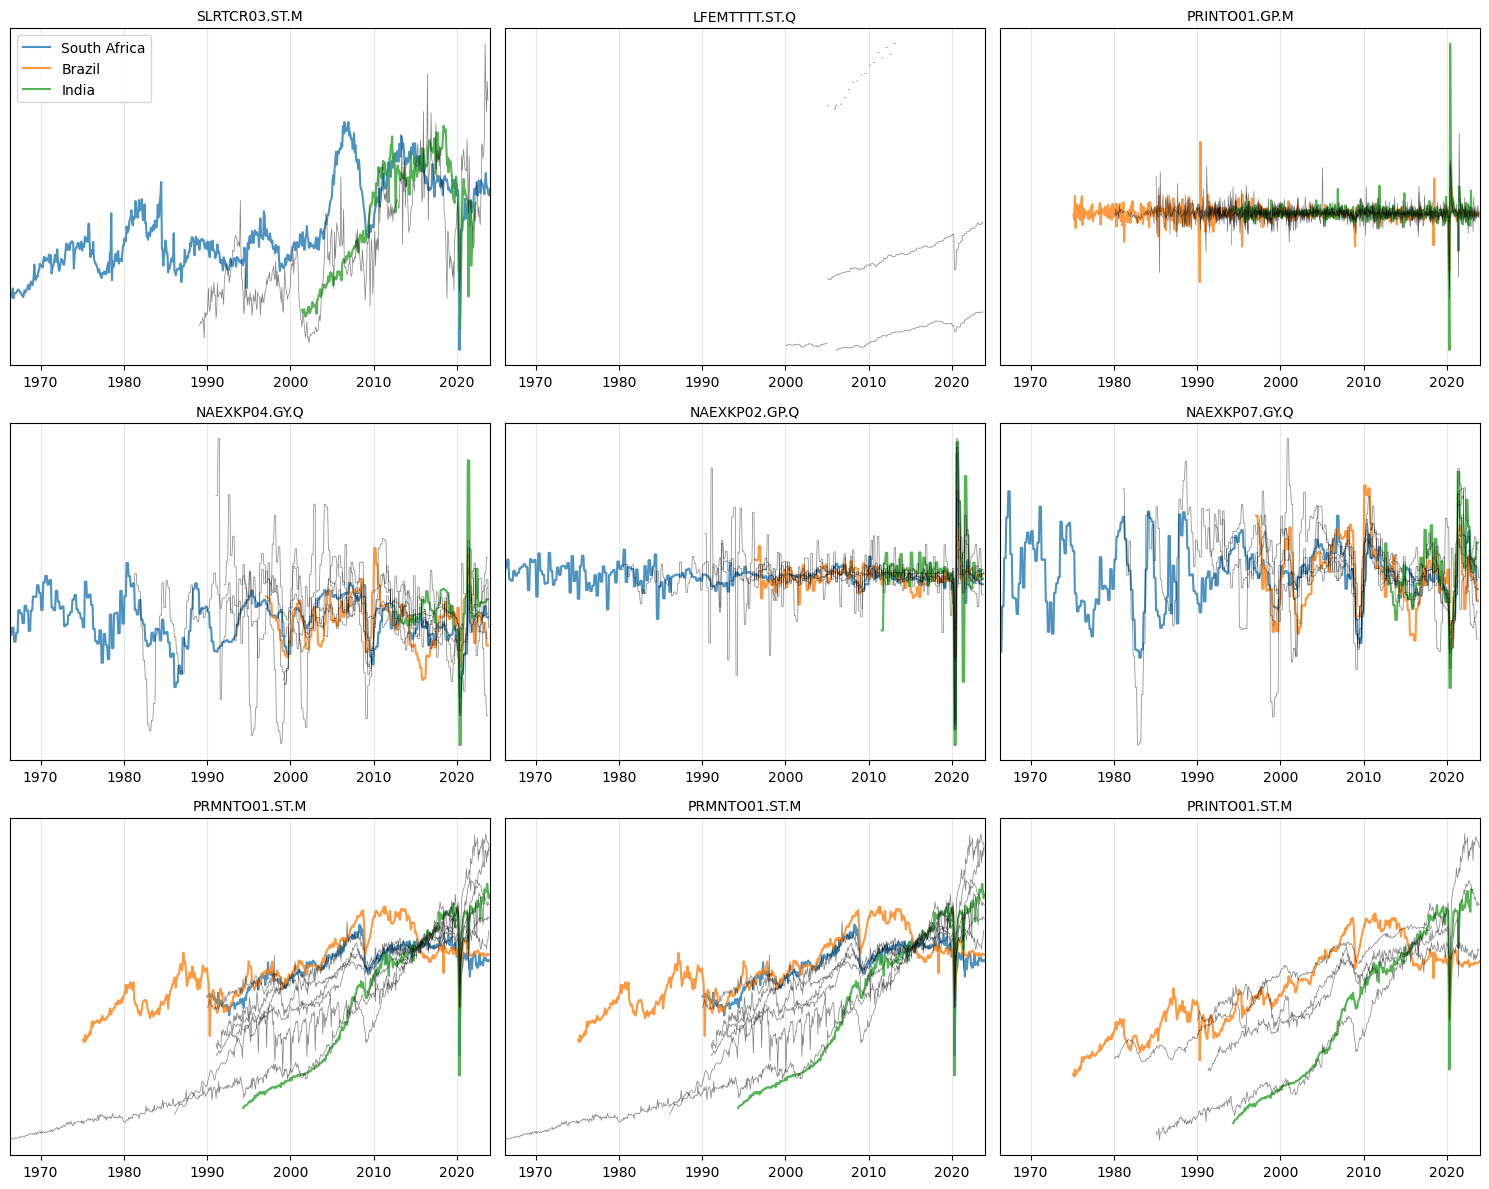

In [ ]:
from src.data.processor import PreprocessPipeline
from src.data.data_utilities import upload_to_huggingface

# (8022, 61)
pipeline = PreprocessPipeline("OECD", subset="emerging")
# drop 1082 static rows
pipeline.drop_static()
# resample the data to monthly frequency to ensure no gaps
pipeline.resample(frequency='M')
# forward fill quarterly columns to monthly resolution
Q_columns = [col for col in pipeline.df.columns if col.endswith('.Q')]
pipeline.forward_fill(columns=Q_columns, n=2, latest_only=False) # forward fill 33012 values
# trim timeseries to period with more than 40% completeness
# (1966-04-30 onwards)
pipeline.trim_timeseries(completeness=0.4)

pipeline.plot_sample(countries = ['South Africa', 'Brazil', 'India'])

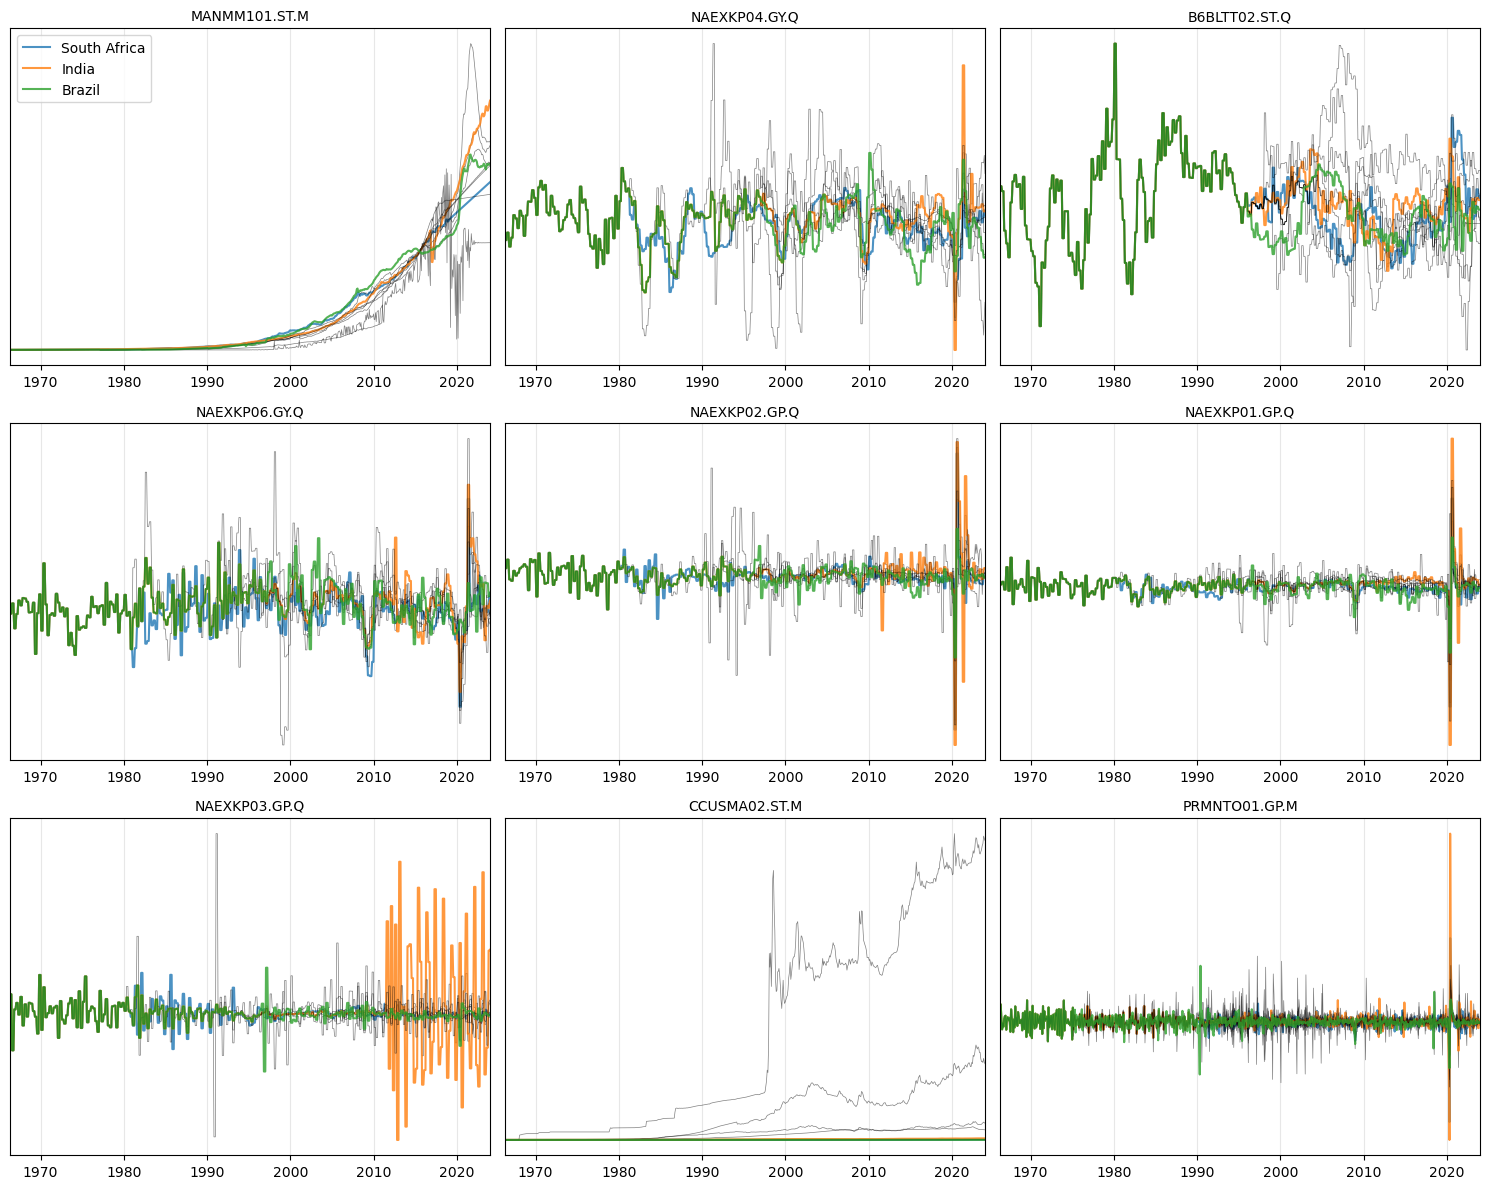

In [ ]:
# drop column LOLITOAA.ST.M (a proxy crisis label)
# drop 34 columns with less than 40% completeness
pipeline.drop_columns(columns=['LOLITOAA.ST.M'], completeness=0.4)

# obtain an imputation mask to perform imputation
# 1. imputation of data where there is an observation before and after
mask = pipeline.get_imputation_mask(include_before=False, include_after=False)
pipeline.knn_iterative_imputer(mask=mask, k=5) # 15 values imputed
# trim timeseries to period with more than 70% completeness
# (1966-04-30 onwards)
pipeline.trim_timeseries(completeness=0.7)

# 2. imputation of data where there is an observation before but not after
mask = pipeline.get_imputation_mask(include_before=False, include_after=True)
pipeline.knn_iterative_imputer(mask=mask, k=5) # 1870 values imputed
pipeline.arima_fill() # 1799 values imputed

# 3. backfill with global median and zero
pipeline.backfill(fill='median') # backfill 58249 values with global median
pipeline.backfill(fill='zero') # backfill 6 values with 0

# trim timeseries to period with more than 95% completeness
# (1966-04-30 onwards)
pipeline.trim_timeseries(completeness=0.95)

pipeline.plot_sample(countries = ['South Africa', 'Brazil', 'India'])

In [ ]:
# Rename "China (People's Republic of)" to "China" for consistency
pipeline.df['Country'] = pipeline.df['Country'].replace("China (People's Republic of)", 'China')
# Rename "Türkiye" to "Turkey" for consistency
pipeline.df['Country'] = pipeline.df['Country'].replace("Türkiye", 'Turkey')

# if a column is all NaN or all zero for a country, fill with zero
# (equivalent to no data or no relevance)
pipeline.zero_fill()

# (6922, 26)
print(pipeline.df.shape)
upload_to_huggingface(pipeline.df.set_index('Date'), repo_name=f"imputed-oecd", config_name="emerging")

In [13]:
display(pipeline.df)

,Country,Date,B6BLTT02.ST.Q,CCUSMA02.ST.M,CPALTT01.ST.M,IRSTCI01.ST.M,LORSGPRT.ST.M,MABMM301.GP.M,MABMM301.GY.M,MABMM301.ST.M,...,NAEXKP03.GY.Q,NAEXKP04.GP.Q,NAEXKP04.GY.Q,NAEXKP06.GP.Q,NAEXKP06.GY.Q,NAEXKP07.GP.Q,NAEXKP07.GY.Q,PRMNTO01.GP.M,PRMNTO01.GY.M,PRMNTO01.ST.M
11,Brazil,1966-05-31,0.202576,0.363393,1.557978,5.000000,100.496223,1.344543,7.993788,0.117500,...,8.146447,-6.479555,-2.979521,-0.316701,1.627745,-4.019705,-26.786057,8.691644,21.854991,8.786865
18,Brazil,1966-06-30,0.202576,0.363393,1.567010,5.000000,100.437663,1.105807,9.018489,0.118999,...,8.146447,-6.479555,-2.979521,-0.316701,1.627745,-4.019705,-26.786057,1.631082,27.194180,8.930186
25,Brazil,1966-07-31,-0.179747,0.363393,1.567010,6.000000,100.373244,1.264364,10.053563,0.120680,...,-0.232607,6.701586,-0.219369,3.458772,5.177825,12.876598,-8.725433,-3.333004,18.143403,8.632543
37,Brazil,1966-08-31,-0.179747,0.363393,1.571526,6.000000,100.302660,0.841085,10.299590,0.121634,...,-0.232607,6.701586,-0.219369,3.458772,5.177825,12.876598,-8.725433,-0.241926,12.917905,8.611658
50,Brazil,1966-09-30,-0.179747,0.363393,1.594105,6.000000,100.225782,0.487799,10.507470,0.122293,...,-0.232607,6.701586,-0.219369,3.458772,5.177825,12.876598,-8.725433,-2.045994,10.888959,8.435464
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6880,Turkey,2023-08-31,-2.674935,26.943078,619.494599,11.672612,100.760060,1.420795,15.978703,86.244709,...,3.696508,5.418390,14.333001,5.395408,0.730811,2.297029,14.027425,-1.327140,2.339986,148.700000
6885,Turkey,2023-09-30,-2.675234,26.999081,648.939885,13.459049,100.828156,1.422261,15.979542,86.267119,...,4.236740,3.855693,10.157560,3.324592,1.018597,2.125563,11.816729,-0.348815,3.193156,148.354541
6895,Turkey,2023-10-31,-2.675167,27.860200,671.224361,11.939603,100.532350,1.422371,15.979827,86.268284,...,4.199154,3.370851,9.363814,3.019084,1.598157,2.106434,10.798504,-0.207970,3.382248,148.246804
6908,Turkey,2023-11-30,-2.675417,28.637914,693.247885,11.763032,100.534829,1.422248,15.979720,86.268009,...,4.104379,3.407539,9.632216,3.203344,1.784894,2.043250,10.787204,-0.278973,3.447969,148.252745


### JST Macroeconomic Database

The JST data set provides extra macroeconomic history for developed nations, going back to the 1800s. Some of these variables are sufficiently general and are indeed measured for emerging markets. This includes: population, GDP, consumer prices, imports, exports, exchange rates, interest rates, etc. However, these exist in siloed databases and may not be of the same moderated quality as the JST database. Additionally, as many of these variables correlate strongly with the measured World Bank and OECD indicators, can assume that the value add of this information is minimal. With more time, a more thorough gap filling technique could have been explored to curate a similar macroeconomic history database for emerging markets.

In [ ]:
from src.data.processor import PreprocessPipeline
from src.data.data_utilities import upload_to_huggingface
import pandas as pd

pipeline = PreprocessPipeline("JST", subset="developed") # only developed
# trim timeseries to period more than 80% completeness
# (1872-01-01 onwards)
pipeline.trim_timeseries(completeness=0.8)
# drop 5 static columns
pipeline.drop_static()
# drop categorical variables with no specific added value
# drop 12 columns with less than 80% completeness
pipeline.drop_columns(columns=['iso', 'ifs', 'peg', 'peg_strict', 'peg_type', 'peg_base'], completeness=0.8)
# resample the data to annual frequency to ensure no gaps
pipeline.resample(frequency='Y')
# drop Country = Ireland
pipeline.df = pipeline.df[~(pipeline.df['Country'] == "Ireland")]
# perform global imputation using KNN
pipeline.knn_iterative_imputer(k=5) # 4887 values imputed

upload_to_huggingface(pipeline.df.set_index('Date'), repo_name=f"imputed-jst", config_name="developed")

In [15]:
display(pipeline.df)

,Country,Date,pop,rgdpmad,rgdpbarro,rconsbarro,gdp,iy,cpi,ca,...,ltd,noncore,eq_tr,bond_tr,bill_rate,eq_capgain,eq_dp,bond_rate,eq_div_rtn,safe_tr
0,Australia,1872-12-31,1722.000000,3553.426249,15.044247,21.085006,227.40,0.130438,2.541667,7.867636,...,94.909546,26.860411,0.176749,0.062041,0.0460,0.108945,0.062997,0.047373,0.069861,0.053520
1,Australia,1873-12-31,1769.000000,3823.629169,16.219443,23.254910,266.54,0.124986,2.541667,-11.047833,...,101.708099,28.645016,0.151686,0.055904,0.0440,0.083086,0.064484,0.046720,0.069842,0.050569
2,Australia,1874-12-31,1822.000000,3834.796926,16.268228,23.458050,287.58,0.141960,2.666667,-5.563959,...,102.079346,28.298048,0.191481,0.055027,0.0450,0.119389,0.063503,0.046533,0.071085,0.050302
3,Australia,1875-12-31,1874.000000,4138.207044,17.592107,25.669505,300.74,0.160564,2.750000,-7.908737,...,101.909348,28.049749,0.124408,0.056091,0.0460,0.057059,0.063643,0.045073,0.067274,0.050975
4,Australia,1876-12-31,1929.000000,4007.257646,17.019033,24.806161,311.26,0.167878,2.791667,-6.952113,...,100.686775,28.126993,0.118815,0.057385,0.0460,0.054104,0.060223,0.045659,0.063481,0.051414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2528,United States,2016-12-31,322701.246359,33012.767871,108.756035,108.051774,18695.10,0.195831,178.575038,-397.573000,...,70.908554,15.484300,0.036493,0.002278,0.0040,0.014868,0.021309,0.018417,0.021626,0.003139
2529,United States,2017-12-31,324756.935396,33543.679862,110.591099,109.978043,19479.60,0.204547,182.415361,-361.702000,...,71.369423,15.200243,0.193025,0.025167,0.0100,0.170363,0.019363,0.023300,0.022662,0.017584
2530,United States,2018-12-31,326497.132575,34338.770756,113.306861,112.567306,20527.20,0.208586,186.862052,-438.241000,...,72.055006,14.785629,0.142075,-0.017138,0.0183,0.121093,0.018716,0.029100,0.020982,0.000581
2531,United States,2019-12-31,328018.681916,34961.835051,115.229692,114.509455,21372.60,0.210205,190.247600,-472.145000,...,71.251307,14.108976,0.081637,0.118668,0.0216,0.061144,0.019312,0.021442,0.020492,0.070134


### Bonus: Yahoo Finance
Yahoo Finance data was also compiled to add additional featues for the most recent years. The following tickers were chosen to augment the post-2000 data corpus:

1. Emerging Market ETFs
- IEMG - iShares Core MSCI Emerging Markets ETF
- VWO - Vanguard FTSE Emerging Markets ETF
- EEM - iShares MSCI Emerging Markets ETF
- SCHE - Schwab Emerging Markets Equity ETF
- SPEM - SPDR Portfolio Emerging Markets ETF
- EEMS - iShares MSCI Emerging Markets Small-Cap ETF
- FRDM - Freedom 100 Emerging Markets ETF
- EMQQ - The Emerging Markets Internet ETF
- ESGE - iShares ESG Aware MSCI EM ETF
- EMGF - iShares Emerging Markets Equity Factor ETF
- FNDE - Schwab Fundamental Emerging Markets Equity ETF
- EMHY - iShares JP Morgan EM High Yield Bond ETF
- EMB - iShares J.P. Morgan USD Emerging Markets Bond ETF
- HYEM - VanEck Emerging Markets High Yield Bond ETF

2. Global REITs
- REET - iShares Global REIT ETF
- SRET - Global X SuperDividend REIT ETF
- VNQI - Vanguard Global ex-U.S. Real Estate ETF
- IFGL - iShares International Developed Real Estate ETF
- VNQ - Vanguard Real Estate ETF stands
- XLRE - Real Estate Select Sector SPDR Fund
- SCHH - Schwab US REIT ETF
- IYR - iShares U.S. Real Estate ETF
- USRT - iShares Core U.S. REIT ETF
- EMRE - Guggenheim Emerging Market Real Estate ETF
- IFAS - iShares Asia Developed Real Estate ETF

3. Current-Exposed ETFs
- FXY - Invesco CurrencyShares Japanese Yen Trust
- FXE - Invesco CurrencyShares Euro Trust
- FXF - Invesco CurrencyShares Swiss Franc Trust
- UUP - Invesco DB US Dollar Index Bullish Fund
- CEW - WisdomTree Emerging Currency Strategy Fund
- FLKR - Franklin FTSE South Korea ETF
- EWY - iShares MSCI South Korea ETF
- EWT - iShares MSCI Taiwan ETF
- EWS - iShares MSCI Singapore ETF
- EWM - iShares MSCI Malaysia ETF
- EIDO - iShares MSCI Indonesia ETF
- THD - iShares MSCI Thailand ETF
- FXI - iShares China Large-Cap ETF
- ASHR - Xtrackers Harvest CSI 300 China A-Shares ETF
- EWZ - iShares MSCI Brazil ETF
- INDA - iShares MSCI India ETF
- EZA - iShares MSCI South Africa ETF

4. Foreign Exchange
- INR=X - USD / Indian Rupee
- BRL=X - USD / Brazilian Real	
- ZAR=X - USD / South African Rand
- TRY=X - USD / Turkish Lira
- IDR=X - USD / Indonesian Rupiah
- THB=X - USD / Thai Baht
- MXN=X - USD / Mexican Peso
- RUB=X - USD / Russian Ruble
- COP=X - USD / Colombian Peso
- PHP=X - USD / Philippine Peso

These tickers are listed in `src/config.json` to be read by the `YahooFinanceDataLoader` which internally performs some feature engineering to create useful features at the monthly frequency. These include:
1. 52 Week High: maximum closing price over 252 trading days window
2. 52 Week Low: minimum closing price over 252 trading days window
3. New High: boolean for if current close >= 52 Week High
4. New Low: boolean for if current close <= 52 Week Low
5. High Low Difference: difference between daily high and low
6. Close Open Difference: difference between daily close and open
7. Volatility: standard deviation of % change over 21 trading days * square root of 252 trading days

In [ ]:
from src.data.loader import YahooFinanceDataLoader

loader = YahooFinanceDataLoader(config_path = '../src/config.json')
data = loader.run_data_pipeline()
print("Yahoo Finance Data Download completed successfully.")
print(f"Dataframe has size {data.shape}") # (7457, 625)

In [ ]:
from src.data.processor import PreprocessPipeline
from datasets import load_dataset
from src.data.data_utilities import upload_to_huggingface

data = load_dataset(f"{username}/yahoofinance-download")['train'].to_pandas()
pipeline = PreprocessPipeline("YAHOOFINANCE", df = data)
pipeline.drop_static()
pipeline.backfill(fill='zero')
pipeline.forward_fill(latest_only=False) # forward fill last recorded values

data_dict = {'train': pipeline.df.set_index('Date')}
upload_to_huggingface(data_dict, repo_name=f"imputed-yahoofinance", config_name="train")

In [ ]:
display(pipeline.df)

## Merging

When merging these datasets, there are two options to aggregate: annual and monthly. Recall that World Bank and JST provided data at the annual resolution and OECD is at the monthly resolution.

Recall that the OECD data has limited coverage for emerging markets as only a few are represented in the dataset. To combat this, we can merge the data with JST and World Bank, forward filling the annual values to monthly resolution, and using KNN-based imputation to fill the OECD data based on nearest neighbors by World Bank and JST data.

In [2]:
from datasets import load_dataset

developed_wb = load_dataset(f"{username}/imputed-worldbank", 'developed')['train'].to_pandas()
emerging_wb = load_dataset(f"{username}/imputed-worldbank", 'emerging')['train'].to_pandas()
developed_jst = load_dataset(f"{username}/imputed-jst", 'developed')['train'].to_pandas()

developed_countries = developed_wb['Country'].unique().tolist()
emerging_countries = emerging_wb['Country'].unique().tolist()

In [ ]:
import pandas as pd
from src.data.processor import PreprocessPipeline

merged_wb = pd.concat([developed_wb, emerging_wb], ignore_index=True)
merged = pd.merge(merged_wb, developed_jst, on = ['Country', 'Date'], how='left')

pipeline = PreprocessPipeline("WORLDBANK-JST", df=merged)
# perform history-based KNN imputation
pipeline.knn_iterative_imputer(distance_metric='manhattan', k=3) # imputed 1632 values
pipeline.drop_static() # drop 0 rows/columns
# resample the data to annual frequency to ensure no gaps
pipeline.resample(frequency='Y')
# if a column is all NaN or all zero for a country, fill with zero
# (equivalent to no data or no relevance)
pipeline.zero_fill() # fill 300560 values with 0
pipeline.knn_iterative_imputer(distance_metric='manhattan', k=5) # imputed 3361 values

pipeline.backfill('median') # backfill 102240 values with global median
pipeline.backfill('zero') # backfill 0 values with 0

The `DataSplitter` can perform three types of splits:
1. Custom train-test split, provided a cut-off date
2. Geographic train-test split, which groups countries such that they match, as much as possible, the specified train and test proportions while also balancing label porportions
3. Temporal train-test split, which finds a cut-off date such that the train and test split match, as much as possible, the specified train and test proportions while also balancing label proportions. This method accepts a weighting factor `beta` to balance the deviations between actual train/test proportions and label proportions.

To perform and test various splits, initialize the `DataSplitter` and use `.get_split_info()` to understand the propoerties of the train and test split.

```python
from src.data.splitter import DataSplitter

# returns information on geographic split of the data
splitter = DataSplitter(geographic=True, train_prop=0.8, test_prop=0.2)
splitter.get_split_info(data)

# returns information on temporal split of the data
splitter = DataSplitter(geographic=False, train_prop=0.8, test_prop=0.2)
splitter.get_split_info(data, beta = 0.8)

# returns information on custom temporal split of the data
splitter = DataSplitter(cutoff_date='2010-12-31', train_prop=0.8, test_prop=0.2)
splitter.get_split_info(data)

# overwrites any stored split with custom date
splitter.perform_split(data, date = '2010-12-31')
# to return the actual data, use get_split()
train_df, y_train = splitter.get_split(data, 'train')
test_df, y_test = splitter.get_split(data, 'test')

# to return the split date
splitter.get_split_date()
```

When splitting a merged dataset that contains both developed and emerging market data, be sure to check the train and test label proportions in the developed and emerging set separately. This can be done by passing the relevant subset of the data into the `.get_split_info()` function.

In [ ]:
from src.data.splitter import DataSplitter
from src.data.data_utilities import upload_to_huggingface

developed = pipeline.df[pipeline.df['Country'].isin(developed_countries)]
emerging = pipeline.df[pipeline.df['Country'].isin(emerging_countries)]

splitter = DataSplitter(cutoff_date = '2006-12-31')
developed_train, _ = splitter.split(df=developed, split='train')
developed_test, _ = splitter.split(df=developed, split='test')
emerging_train, _ = splitter.split(df=emerging, split='train')
emerging_test, _ = splitter.split(df=emerging, split='test')

print(splitter.get_split_info(developed))
print(splitter.get_split_info(emerging))

data_dict = {'train': developed_train.set_index('Date'), 'test': developed_test.set_index('Date')}
upload_to_huggingface(data_dict, repo_name=f"baseline-annual", config_name="developed")
data_dict = {'train': emerging_train.set_index('Date'), 'test': emerging_test.set_index('Date')}
upload_to_huggingface(data_dict, repo_name=f"baseline-annual", config_name="emerging")

In [7]:
from datasets import load_dataset

developed = load_dataset(f"{username}/imputed-oecd", 'developed')['train'].to_pandas()
emerging = load_dataset(f"{username}/imputed-oecd", 'emerging')['train'].to_pandas()

developed_train = load_dataset(f"{username}/baseline-annual", 'developed')['train'].to_pandas()
developed_test = load_dataset(f"{username}/baseline-annual", 'developed')['test'].to_pandas()
emerging_train = load_dataset(f"{username}/baseline-annual", 'emerging')['train'].to_pandas()
emerging_test = load_dataset(f"{username}/baseline-annual", 'emerging')['test'].to_pandas()

In [ ]:
from src.data.processor import PreprocessPipeline
from src.data.splitter import DataSplitter
from src.data.data_utilities import upload_to_huggingface
import pandas as pd

# merge across datasets and across time for imputation
d_annual = pd.concat([developed_train, developed_test], ignore_index=True)
developed = pd.merge(d_annual, developed, on=['Country', 'Date'], how='outer')
e_annual = pd.concat([emerging_train, emerging_test], ignore_index=True)
emerging = pd.merge(e_annual, emerging, on=['Country', 'Date'], how='outer')

common_columns = list(set(developed.columns) & set(emerging.columns))
developed = developed[common_columns]
emerging = emerging[common_columns]

annual_columns = [col for col in developed_train.columns.tolist() if col not in ['Country', 'Date']]
pipeline = PreprocessPipeline("Developed-monthly", df=developed)
pipeline.resample('M')
# forward fill annual columns by 11 months
pipeline.forward_fill(n=11, latest_only=False, columns=annual_columns) # forward fill 2566575 values
# if a column is all NaN or all zero for a country, fill with zero
# (equivalent to no data or no relevance)
pipeline.zero_fill() # fill 57242 values with 0
# backfill with global median and zero
pipeline.backfill('median') # backfill 1354 values with global median
pipeline.backfill('zero') # backfill 75565 values with 0

# split based on cutoff date
splitter = DataSplitter(cutoff_date='2006-12-31')
d_train, _ = splitter.split(df=pipeline.df, split='train')
d_test, _ = splitter.split(df=pipeline.df, split='test')
data_dict = {'train': d_train.set_index('Date'), 'test': d_test.set_index('Date')}
upload_to_huggingface(data_dict, repo_name="imputed-monthly", config_name="developed")

In [ ]:
developed = pipeline.df.copy()

annual_columns = [col for col in emerging_train.columns.tolist() if col not in ['Country', 'Date']]
pipeline = PreprocessPipeline("Emerging-monthly", df=emerging)
pipeline.resample('M')
# forward fill annual columns by 11 months
pipeline.forward_fill(n=11, latest_only=False, columns=annual_columns) # forward fill 1426950 values
# if a column is all NaN or all zero for a country, fill with zero
# (equivalent to no data or no relevance)
pipeline.zero_fill()
# concatenate with the developed markets data for history-based KNN imputation
emerging_countries = pipeline.df['Country'].unique().tolist()
developed_countries = developed['Country'].unique().tolist()
pipeline.df = pd.concat([pipeline.df, developed]).reset_index().sort_values('Date')

# fill emerging market
pipeline.knn_iterative_imputer(distance_metric='manhattan', k=5) # imputed XX values

# remove developed countries
pipeline.df = pipeline.df[pipeline.df['Country'].isin(emerging_countries)]
pipeline.df = pipeline.df[common_columns]

pipeline.backfill('median') # backfill 0 values with global median
pipeline.backfill('zero') # backfill 0 values with 0

# split based on cutoff date
splitter = DataSplitter(cutoff_date='2006-12-31')
e_train, _ = splitter.split(df=pipeline.df, split='train')
e_test, _ = splitter.split(df=pipeline.df, split='test')
data_dict = {'train': e_train.set_index('Date'), 'test': e_test.set_index('Date')}
upload_to_huggingface(data_dict, repo_name="imputed-monthly", config_name="emerging")

In [18]:
display(pipeline.df)

,BM.KLT.DINV.WD.GD.ZS,NE.TRD.GNFS.ZS,NE.IMP.GNFS.KD,NY.GDP.PCAP.KD,NY.GDP.PCAP.CN,FM.AST.CGOV.ZG.M3,noncore,FM.LBL.BMNY.IR.ZS,NV.SRV.TOTL.ZS,imports,...,NE.CON.TOTL.KN,stir,BM.KLT.DINV.CD.WD,NE.IMP.GNFS.KN,NY.GDY.TOTL.KN,NY.GDP.FCST.KN,NY.GDS.TOTL.ZS,DT.TDS.DECT.CD,NE.RSB.GNFS.CD,ltd
0,0.0,28.092076,2.016610e+10,14982.601493,2205.087339,0.000000,0.0,0.000000,0.000000,0.0,...,2.707736e+11,0.0,0.0,3.462693e+10,4.919624e+11,0.000000e+00,28.822520,0.000000e+00,2.609600e+08,0.0
1,0.0,28.092076,2.016610e+10,14982.601493,2205.087339,0.000000,0.0,0.000000,0.000000,0.0,...,2.707736e+11,0.0,0.0,3.462693e+10,4.919624e+11,0.000000e+00,28.822520,0.000000e+00,2.609600e+08,0.0
2,0.0,28.092076,2.016610e+10,14982.601493,2205.087339,0.000000,0.0,0.000000,0.000000,0.0,...,2.707736e+11,0.0,0.0,3.462693e+10,4.919624e+11,0.000000e+00,28.822520,0.000000e+00,2.609600e+08,0.0
3,0.0,28.092076,2.016610e+10,14982.601493,2205.087339,0.000000,0.0,0.000000,0.000000,0.0,...,2.707736e+11,0.0,0.0,3.462693e+10,4.919624e+11,0.000000e+00,28.822520,0.000000e+00,2.609600e+08,0.0
4,0.0,28.092076,2.016610e+10,14982.601493,2205.087339,0.000000,0.0,0.000000,0.000000,0.0,...,2.707736e+11,0.0,0.0,3.462693e+10,4.919624e+11,0.000000e+00,28.822520,0.000000e+00,2.609600e+08,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66560,0.0,64.763607,4.846439e+09,1368.498418,309.457052,51.265889,0.0,10.307708,41.547127,0.0,...,8.506280e+07,0.0,0.0,3.334430e+07,9.011634e+07,8.530095e+07,5.591073,4.542304e+08,-2.957387e+09,0.0
66561,0.0,64.763607,4.846439e+09,1368.498418,309.457052,51.265889,0.0,10.307708,41.547127,0.0,...,8.506280e+07,0.0,0.0,3.334430e+07,9.011634e+07,8.530095e+07,5.591073,4.542304e+08,-2.957387e+09,0.0
66562,0.0,64.763607,4.846439e+09,1368.498418,309.457052,51.265889,0.0,10.307708,41.547127,0.0,...,8.506280e+07,0.0,0.0,3.334430e+07,9.011634e+07,8.530095e+07,5.591073,4.542304e+08,-2.957387e+09,0.0
66563,0.0,64.763607,4.846439e+09,1368.498418,309.457052,51.265889,0.0,10.307708,41.547127,0.0,...,8.506280e+07,0.0,0.0,3.334430e+07,9.011634e+07,8.530095e+07,5.591073,4.542304e+08,-2.957387e+09,0.0


In [19]:
pipeline.df.describe()

,BM.KLT.DINV.WD.GD.ZS,NE.TRD.GNFS.ZS,NE.IMP.GNFS.KD,NY.GDP.PCAP.KD,NY.GDP.PCAP.CN,FM.AST.CGOV.ZG.M3,noncore,FM.LBL.BMNY.IR.ZS,NV.SRV.TOTL.ZS,imports,...,NE.CON.TOTL.KN,stir,BM.KLT.DINV.CD.WD,NE.IMP.GNFS.KN,NY.GDY.TOTL.KN,NY.GDP.FCST.KN,NY.GDS.TOTL.ZS,DT.TDS.DECT.CD,NE.RSB.GNFS.CD,ltd
count,53509.0,53509.000000,5.350900e+04,53509.000000,5.350900e+04,53509.000000,53509.0,53509.000000,53509.000000,53509.0,...,5.350900e+04,53509.0,53509.0,5.350900e+04,5.350900e+04,5.350900e+04,53509.000000,5.350900e+04,5.350900e+04,53509.0
mean,0.0,56.698554,2.472023e+10,5019.351234,9.916345e+05,12.543624,0.0,12.940089,40.800247,0.0,...,6.203316e+13,0.0,0.0,2.926464e+13,9.614655e+13,5.526304e+13,17.996691,3.487447e+09,4.433903e+08,0.0
min,0.0,4.825486,2.921353e+06,137.829005,4.045070e-10,-5379.350669,0.0,0.000000,0.000000,0.0,...,3.128737e+07,0.0,0.0,6.246859e+06,3.533890e+07,0.000000e+00,-86.448598,0.000000e+00,-1.229061e+11,0.0
25%,0.0,34.014797,2.907969e+09,1143.311789,1.831392e+03,0.000000,0.0,1.707146,37.785690,0.0,...,1.395580e+11,0.0,0.0,3.513232e+10,1.769899e+11,1.956846e+10,11.521128,2.021900e+07,-9.068934e+08,0.0
50%,0.0,49.980817,7.868114e+09,2609.488729,6.775318e+03,2.166218,0.0,3.474957,44.536478,0.0,...,3.905075e+11,0.0,0.0,1.349517e+11,5.749832e+11,4.863570e+11,17.424002,1.590509e+08,-7.789667e+07,0.0
75%,0.0,69.464263,2.063023e+10,6604.005463,6.650495e+04,8.110233,0.0,6.064139,52.175554,0.0,...,3.260754e+12,0.0,0.0,9.499589e+11,4.109999e+12,3.611848e+12,27.994273,9.975438e+08,2.609600e+08,0.0
max,0.0,347.720317,2.003261e+12,30218.860458,2.984862e+08,3222.536668,0.0,2875.545610,94.148335,0.0,...,7.537491e+15,0.0,0.0,5.542874e+15,1.205124e+16,1.176322e+16,83.287043,4.286957e+11,5.778470e+11,0.0
std,0.0,30.822615,6.295585e+10,5443.979383,5.678422e+06,152.451218,0.0,111.037126,18.567965,0.0,...,4.377180e+14,0.0,0.0,2.548945e+14,6.969527e+14,5.509625e+14,13.049823,1.568507e+10,2.031821e+10,0.0


## Feature Engineering

We can engineer features using the OECD data to enrich the monthly resolution. Note that as feature engineering can cause data leakage in timeseries data, we separate the train from test datasets. Thereafter, the `FeaturePipeline` object can be called upon to perform the feature engineering.

In [2]:
from datasets import load_dataset
import pandas as pd
from src.data.processor import PreprocessPipeline

developed_train = load_dataset(f"{username}/imputed-monthly", 'developed')['train'].to_pandas()
developed_test = load_dataset(f"{username}/imputed-monthly", 'developed')['test'].to_pandas()
emerging_train = load_dataset(f"{username}/imputed-monthly", 'emerging')['train'].to_pandas()
emerging_test = load_dataset(f"{username}/imputed-monthly", 'emerging')['test'].to_pandas()

developed_countries = developed_train['Country'].unique().tolist()
emerging_countries = emerging_train['Country'].unique().tolist()

# merge developed and emerging datasets
merged_train = pd.concat([developed_train, emerging_train], ignore_index=True)
merged_test = pd.concat([developed_test, emerging_test], ignore_index=True)
merged = pd.concat([merged_train, merged_test], ignore_index=True)

In [3]:
from src.data.splitter import DataSplitter

splitter = DataSplitter(cutoff_date='2006-12-31')
splitter.perform_split(merged)
splitter.get_split_info(merged)

{'train': {'start': Timestamp('1960-01-31 00:00:00'),
  'end': Timestamp('2006-12-31 00:00:00'),
  'count': 48205},
 'test': {'start': Timestamp('2007-01-31 00:00:00'),
  'end': Timestamp('2023-12-31 00:00:00'),
  'count': 18360},
 'total_periods': 66565,
 'proportions': {'train': 0.7241793735446556, 'test': 0.2758206264553444},
 'label_proportions': {'train': 0.16278394357431802,
  'test': 0.0934640522875817}}

The following cell creates some useful features using the OECD data. The choice of columns to engineer features for is informed by some baseline classifiers and feature importance plots that were run on the raw monthly OECD data (not shown).

In [4]:
from src.data.features import FeaturePipeline

money = [col for col in merged.columns if (col.startswith('MABMM301') or col.startswith('MANMM101')) and col.endswith('.M')]
bank_rate = ['IRSTCI01.ST.M']
consumer_price = ['CPALTT01.ST.M']
current_account = ['B6BLTT02.ST.Q']
exchange_rate = ['CCUSMA02.ST.M']
spending = [col for col in merged.columns if (col.startswith('NAEXKP'))]
lowest_avgs = [col for col in merged.columns if col.endswith('.M') and abs(merged[col].mean()) < 1]

features = FeaturePipeline(X = merged, splitter = splitter)
train1, test1 = features.create_rolling_features(
    columns = exchange_rate + spending + bank_rate + money, windows = [3, 6],
    stats = ['mean', 'std', 'min', 'max'],
    suffix = 'rolling' 
)
features.add_features((train1, test1))
train2, test2 = features.create_extreme_binary(
    columns = exchange_rate + spending + current_account + bank_rate + money + consumer_price,
    window = 12, threshold = 0.9, suffix = 'exceeds'
)
features.add_features((train2, test2))
train3, test3 = features.create_exponentially_weighted_averages(
    columns = current_account + money + bank_rate + consumer_price,
    spans = [3, 6], suffix = 'ewm'
)
features.add_features((train3, test3))
train4, test4 = features.create_regression_to_mean(
    columns = lowest_avgs, suffix = 'dist_mean'
)
features.add_features((train4, test4))
train5, test5 = features.create_momentum_features(
    columns = spending + bank_rate + consumer_price,
    window = 3, suffix = 'momentum'
)
features.add_features((train5, test5))
train6, test6 = features.create_volatility_features(
    columns = exchange_rate + spending + current_account + lowest_avgs + bank_rate + consumer_price,
    window = 3, suffix = 'volatility'
)
features.add_features((train6, test6))
train7, test7 = features.create_seasonal_decomposition_features(
    columns = exchange_rate + current_account + consumer_price + money,
    model = 'additive'
)
features.add_features((train7, test7))

In [ ]:
postprocess = PreprocessPipeline("OECD-ALL-FEATURES", df=features.X_train)
X_train_all = postprocess.df

postprocess = PreprocessPipeline("OECD-ALL-FEATURES", df=features.X_test)
X_test_all = postprocess.df

# Split into developed and emerging
X_train_developed = X_train_all[X_train_all['Country'].isin(developed_countries)]
X_test_developed = X_test_all[X_test_all['Country'].isin(developed_countries)]
X_train_emerging = X_train_all[X_train_all['Country'].isin(emerging_countries)]
X_test_emerging = X_test_all[X_test_all['Country'].isin(emerging_countries)]

# Upload to huggingface
from src.data.data_utilities import upload_to_huggingface
data_dict = {'train': X_train_developed.set_index('Date'), 'test': X_test_developed.set_index('Date')}
upload_to_huggingface(data_dict, repo_name="imputed-monthly", config_name="developed")
data_dict = {'train': X_train_emerging.set_index('Date'), 'test': X_test_emerging.set_index('Date')}
upload_to_huggingface(data_dict, repo_name="imputed-monthly", config_name="emerging")

In [6]:
display(X_train_developed)

,Country,BM.KLT.DINV.WD.GD.ZS,NE.TRD.GNFS.ZS,NE.IMP.GNFS.KD,NY.GDP.PCAP.KD,NY.GDP.PCAP.CN,FM.AST.CGOV.ZG.M3,noncore,FM.LBL.BMNY.IR.ZS,NV.SRV.TOTL.ZS,...,MABMM301.GY.M_seasonal_trend,MABMM301.ST.M_seasonal_trend,MABMM301.GP.M_seasonal_trend,CCUSMA02.ST.M_seasonal_residual,B6BLTT02.ST.Q_seasonal_residual,CPALTT01.ST.M_seasonal_residual,MANMM101.ST.M_seasonal_residual,MABMM301.GY.M_seasonal_residual,MABMM301.ST.M_seasonal_residual,MABMM301.GP.M_seasonal_residual
1587,Australia,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1588,Australia,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1589,Australia,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1590,Australia,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1591,Australia,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44497,United States,0.403330,25.638557,2.051453e+12,52649.571306,44123.399647,0.0,27.009687,0.0,0.0,...,5.350446,57.493815,0.459681,0.0,-0.398837,0.647667,-1.355236,-0.066673,-0.114166,-0.022796
44498,United States,0.403330,25.638557,2.051453e+12,52649.571306,44123.399647,0.0,27.009687,0.0,0.0,...,5.414950,57.761178,0.464761,0.0,-0.422721,0.031484,-1.076558,-0.261528,-0.116066,-0.051960
44499,United States,0.403330,25.638557,2.051453e+12,52649.571306,44123.399647,0.0,27.009687,0.0,0.0,...,5.493490,58.047394,0.494800,0.0,0.324426,-0.564172,-0.281032,-0.148344,0.029628,0.251427
44500,United States,0.403330,25.638557,2.051453e+12,52649.571306,44123.399647,0.0,27.009687,0.0,0.0,...,5.589242,58.348243,0.517859,0.0,0.270404,-0.707469,0.168983,0.016490,0.040928,0.010356


In [7]:
display(X_test_developed)

,Country,BM.KLT.DINV.WD.GD.ZS,NE.TRD.GNFS.ZS,NE.IMP.GNFS.KD,NY.GDP.PCAP.KD,NY.GDP.PCAP.CN,FM.AST.CGOV.ZG.M3,noncore,FM.LBL.BMNY.IR.ZS,NV.SRV.TOTL.ZS,...,MABMM301.GY.M_seasonal_trend,MABMM301.ST.M_seasonal_trend,MABMM301.GP.M_seasonal_trend,CCUSMA02.ST.M_seasonal_residual,B6BLTT02.ST.Q_seasonal_residual,CPALTT01.ST.M_seasonal_residual,MANMM101.ST.M_seasonal_residual,MABMM301.GY.M_seasonal_residual,MABMM301.ST.M_seasonal_residual,MABMM301.GP.M_seasonal_residual
612,Australia,3.217794,41.559447,1.833708e+11,51553.968597,48877.153285,0.0,44.172163,0.0,0.0,...,13.241458,44.942741,1.251046,0.015097,0.083972,0.0,-0.297131,-0.394566,-0.424579,-0.214204
613,Australia,3.217794,41.559447,1.833708e+11,51553.968597,48877.153285,0.0,44.172163,0.0,0.0,...,13.752099,45.544984,1.326064,0.024717,0.182475,0.0,-0.329949,-0.250597,-0.374678,0.120467
614,Australia,3.217794,41.559447,1.833708e+11,51553.968597,48877.153285,0.0,44.172163,0.0,0.0,...,14.302239,46.185401,1.391326,0.015691,0.280978,0.0,-0.296562,0.103938,-0.217625,0.356244
615,Australia,3.217794,41.559447,1.833708e+11,51553.968597,48877.153285,0.0,44.172163,0.0,0.0,...,14.925061,46.875080,1.476698,-0.015686,-0.270425,0.0,-0.170609,-0.815891,-0.261787,-0.038752
616,Australia,3.217794,41.559447,1.833708e+11,51553.968597,48877.153285,0.0,44.172163,0.0,0.0,...,15.633386,47.633984,1.598398,0.003598,-0.168355,0.0,-0.161733,-1.535313,-0.446581,-0.374352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16927,United States,1.493873,26.891690,3.542496e+12,64198.432488,77860.911291,0.0,12.906998,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
16928,United States,1.493873,26.891690,3.542496e+12,64198.432488,77860.911291,0.0,12.906998,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
16929,United States,1.493873,26.891690,3.542496e+12,64198.432488,77860.911291,0.0,12.906998,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
16930,United States,1.493873,26.891690,3.542496e+12,64198.432488,77860.911291,0.0,12.906998,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000


In [8]:
display(X_train_emerging)

,Country,BM.KLT.DINV.WD.GD.ZS,NE.TRD.GNFS.ZS,NE.IMP.GNFS.KD,NY.GDP.PCAP.KD,NY.GDP.PCAP.CN,FM.AST.CGOV.ZG.M3,noncore,FM.LBL.BMNY.IR.ZS,NV.SRV.TOTL.ZS,...,MABMM301.GY.M_seasonal_trend,MABMM301.ST.M_seasonal_trend,MABMM301.GP.M_seasonal_trend,CCUSMA02.ST.M_seasonal_residual,B6BLTT02.ST.Q_seasonal_residual,CPALTT01.ST.M_seasonal_residual,MANMM101.ST.M_seasonal_residual,MABMM301.GY.M_seasonal_residual,MABMM301.ST.M_seasonal_residual,MABMM301.GP.M_seasonal_residual
0,Afghanistan,0.0,28.092076,2.016610e+10,14982.601493,2205.087339,0.000000,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Afghanistan,0.0,28.092076,2.016610e+10,14982.601493,2205.087339,0.000000,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Afghanistan,0.0,28.092076,2.016610e+10,14982.601493,2205.087339,0.000000,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,0.0,28.092076,2.016610e+10,14982.601493,2205.087339,0.000000,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,0.0,28.092076,2.016610e+10,14982.601493,2205.087339,0.000000,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48200,Zimbabwe,0.0,76.043707,1.461431e+09,1088.076995,0.184505,49.983620,0.0,26.884105,48.681379,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48201,Zimbabwe,0.0,76.043707,1.461431e+09,1088.076995,0.184505,49.983620,0.0,26.884105,48.681379,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48202,Zimbabwe,0.0,76.043707,1.461431e+09,1088.076995,0.184505,49.983620,0.0,26.884105,48.681379,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48203,Zimbabwe,0.0,76.043707,1.461431e+09,1088.076995,0.184505,49.983620,0.0,26.884105,48.681379,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
display(X_test_emerging)

,Country,BM.KLT.DINV.WD.GD.ZS,NE.TRD.GNFS.ZS,NE.IMP.GNFS.KD,NY.GDP.PCAP.KD,NY.GDP.PCAP.CN,FM.AST.CGOV.ZG.M3,noncore,FM.LBL.BMNY.IR.ZS,NV.SRV.TOTL.ZS,...,MABMM301.GY.M_seasonal_trend,MABMM301.ST.M_seasonal_trend,MABMM301.GP.M_seasonal_trend,CCUSMA02.ST.M_seasonal_residual,B6BLTT02.ST.Q_seasonal_residual,CPALTT01.ST.M_seasonal_residual,MANMM101.ST.M_seasonal_residual,MABMM301.GY.M_seasonal_residual,MABMM301.ST.M_seasonal_residual,MABMM301.GP.M_seasonal_residual
0,Afghanistan,0.0,40.065616,1.589587e+09,367.758312,13689.707275,0.272714,0.0,5.988864,39.831024,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Afghanistan,0.0,40.065616,1.589587e+09,367.758312,13689.707275,0.272714,0.0,5.988864,39.831024,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Afghanistan,0.0,40.065616,1.589587e+09,367.758312,13689.707275,0.272714,0.0,5.988864,39.831024,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,0.0,40.065616,1.589587e+09,367.758312,13689.707275,0.272714,0.0,5.988864,39.831024,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,0.0,40.065616,1.589587e+09,367.758312,13689.707275,0.272714,0.0,5.988864,39.831024,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18355,Zimbabwe,0.0,64.763607,4.846439e+09,1368.498418,309.457052,51.265889,0.0,10.307708,41.547127,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18356,Zimbabwe,0.0,64.763607,4.846439e+09,1368.498418,309.457052,51.265889,0.0,10.307708,41.547127,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18357,Zimbabwe,0.0,64.763607,4.846439e+09,1368.498418,309.457052,51.265889,0.0,10.307708,41.547127,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18358,Zimbabwe,0.0,64.763607,4.846439e+09,1368.498418,309.457052,51.265889,0.0,10.307708,41.547127,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
